# Exploratory Data Analysis -- Claims Denial Risk

Univariate and bivariate analysis of `data/claims_history.csv` (3,200 historical
claims with a known `is_denied` outcome). Every chart is followed by a short
**Inference** note. This notebook is exploratory only -- it does not feed the
modeling pipeline (see `src/train.py`); it documents the reasoning behind the
feature choices and data findings in `writeup/writeup.pdf`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.data import load_history

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = load_history("../data/claims_history.csv")
df.shape

(3200, 23)

`load_history` applies the same feature engineering used in the modeling
pipeline (`auth_gap`, `referral_gap`, `payment_ratio`) so this EDA reflects the
exact features the model sees, not just the raw columns.

In [2]:
df.head()

,claim_id,payer_id,payer_type,visit_type,total_billed,expected_payment,num_procedures,num_diagnoses,prior_auth_required,has_prior_auth,...,eligibility_verified,referral_required,referral_present,split,service_month,is_denied,denial_reason,auth_gap,referral_gap,payment_ratio
0,HCLM-00001,P008,Medicaid MCO,Outpatient,4311.44,1404.82,2,5,0,0,...,1,0,0,train,2024-06,1,Payer policy or medical necessity issue,0,0,0.325835
1,HCLM-00002,P001,Commercial,Inpatient,10420.64,6065.91,6,8,1,1,...,1,1,1,train,2024-06,0,NaN,0,0,0.582105
2,HCLM-00003,P010,BCBS,Outpatient,38369.33,20712.61,5,5,0,0,...,1,0,0,train,2024-02,1,Documentation incomplete or missing,0,0,0.539822
3,HCLM-00004,P005,Medicare Advantage,Outpatient,6268.92,2306.49,6,3,1,1,...,1,1,1,validation,2024-09,0,NaN,0,0,0.367925
4,HCLM-00005,P008,Medicaid MCO,Emergency,3986.26,1247.93,8,7,0,1,...,0,1,1,validation,2024-09,1,Patient eligibility could not be verified,0,0,0.313058


In [3]:
df.dtypes

claim_id                       object
payer_id                       object
payer_type                     object
visit_type                     object
total_billed                  float64
expected_payment              float64
num_procedures                  int64
num_diagnoses                   int64
prior_auth_required             int64
has_prior_auth                  int64
is_in_network                   int64
days_to_submit                  int64
missing_documentation_flag      int64
eligibility_verified            int64
referral_required               int64
referral_present                int64
split                          object
service_month                  object
is_denied                       int64
denial_reason                  object
auth_gap                        int64
referral_gap                    int64
payment_ratio                 float64
dtype: object

In [4]:
df.isna().sum()[df.isna().sum() > 0]

denial_reason    2509
dtype: int64

**Inference:** No missing values anywhere except `denial_reason`, which is
only populated for denied claims by design (it doesn't exist before a denial
happens) -- expected, not a data quality issue. Confirms the dataset needs no
imputation.

In [5]:
df["split"].value_counts()

split
train         2122
validation     539
test           539
Name: count, dtype: int64

**Inference:** Train/validation/test are roughly 66% / 17% / 17% of the data
(2,122 / 539 / 539 rows) -- a standard split ratio. We use this column as-is
per the assignment brief rather than re-splitting.

## 1. Univariate Analysis

### 1.1 Target variable

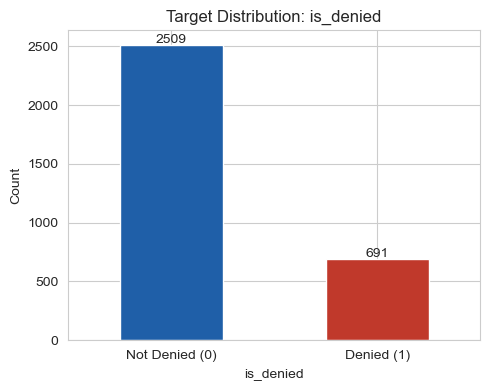

Denial rate: 21.6%


In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
df["is_denied"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#1f5fa8", "#c0392b"]
)
ax.set_xticklabels(["Not Denied (0)", "Denied (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Target Distribution: is_denied")
for i, v in enumerate(df["is_denied"].value_counts().sort_index()):
    ax.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.show()

print(f"Denial rate: {df['is_denied'].mean():.1%}")

**Inference:** The dataset is moderately imbalanced -- about 22% of claims are
denied. Not extreme enough to require synthetic resampling (SMOTE etc.), but
imbalanced enough that plain accuracy would be misleading (a model that always
predicts "not denied" would already score ~78% accuracy while being useless).
This is why the modeling pipeline uses `class_weight="balanced"` and reports
recall@25% / PR-AUC rather than leading with accuracy.

### 1.2 Denial reason (denied claims only)

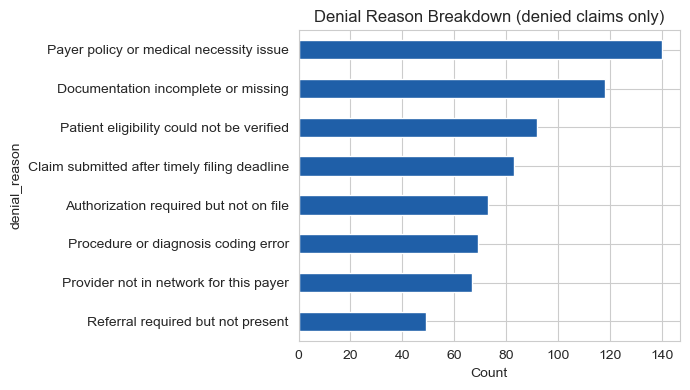

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
df["denial_reason"].value_counts().plot(kind="barh", ax=ax, color="#1f5fa8")
ax.set_xlabel("Count")
ax.set_title("Denial Reason Breakdown (denied claims only)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Inference:** Denial reasons are fairly evenly spread across 8 categories
(9%-20% each) -- no single root cause dominates. This means a front-end review
process needs a checklist covering multiple failure modes (authorization,
documentation, eligibility, referral, timely filing, coding, network), not a
single point fix. `denial_reason` is excluded from model inputs since it only
exists after a denial (target leakage) -- it's used here purely for
descriptive analysis.

### 1.3 Numeric features

In [8]:
numeric_cols = ["total_billed", "expected_payment", "num_procedures", "num_diagnoses", "days_to_submit", "payment_ratio"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_billed,3200.0,12164.406722,13173.400467,522.63,4401.085000,7972.490000,14847.200000,95000.000000
expected_payment,3200.0,6032.162956,6697.618117,192.70,2065.390000,3849.820000,7421.650000,62988.930000
num_procedures,3200.0,3.848438,2.122793,1.00,2.000000,3.000000,5.000000,15.000000
num_diagnoses,3200.0,5.315938,2.594484,1.00,3.000000,5.000000,7.000000,18.000000
days_to_submit,3200.0,19.267187,11.777777,1.00,11.000000,17.000000,25.000000,78.000000
payment_ratio,3200.0,0.496037,0.111637,0.18,0.405621,0.502985,0.582374,0.820001


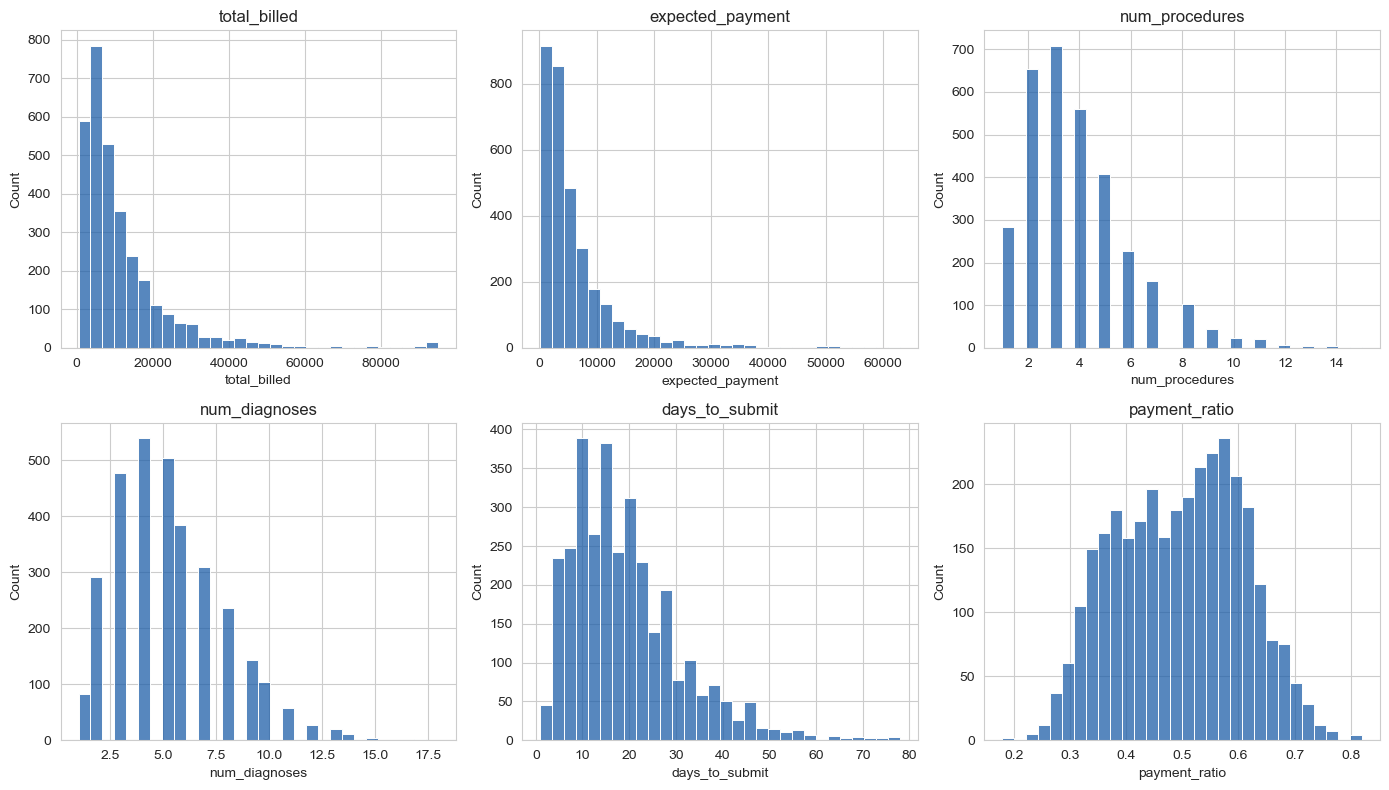

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=30, ax=ax, color="#1f5fa8")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Inference:**
- `total_billed` and `expected_payment` are right-skewed, as billing amounts
  typically are -- most claims are modest, with a long tail of large claims
  (likely inpatient). No negative or zero values, so no cleaning needed.
- `num_procedures` and `num_diagnoses` are discrete counts, roughly
  right-skewed too, consistent with most claims having a handful of codes and
  a few having many.
- `days_to_submit` is right-skewed with most claims submitted within ~20-30
  days, but a tail stretching out to ~80 days -- late-submitted claims are a
  minority but worth flagging (see bivariate section: they correlate with
  denial).
- `payment_ratio` (expected_payment / total_billed) clusters around 0.4-0.6,
  which makes sense as the typical contracted-rate discount insurers apply;
  outlier claims near 0 are worth a second look (heavily discounted or
  disputed pricing).

### 1.4 Categorical features

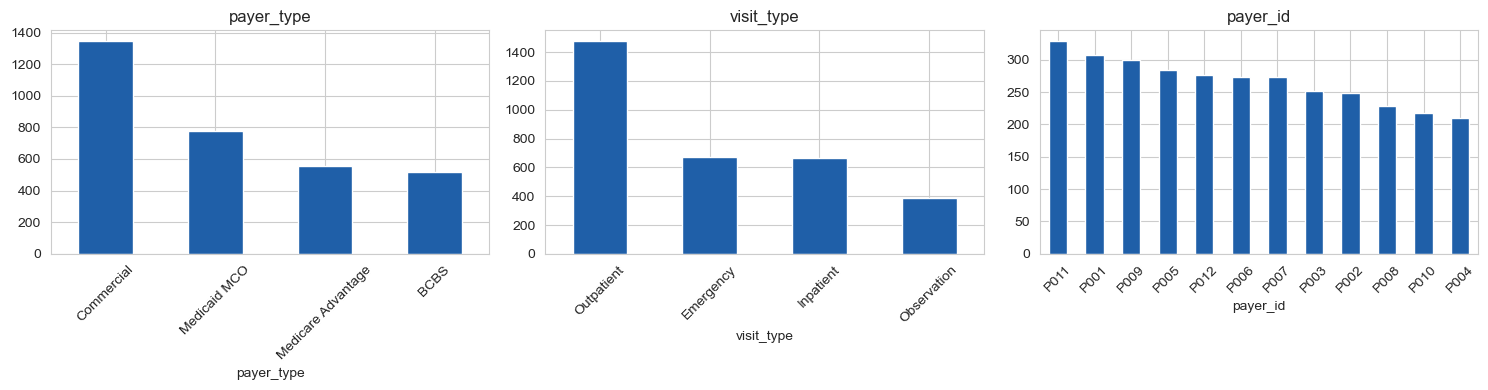

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["payer_type", "visit_type", "payer_id"]):
    df[col].value_counts().plot(kind="bar", ax=ax, color="#1f5fa8")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Inference:** `payer_type` is dominated by Commercial (~42%), with BCBS,
Medicare Advantage, and Medicaid MCO splitting the rest -- no category is so
rare it risks being undertrained. `visit_type` skews toward Outpatient
(~46%), consistent with outpatient care being the highest-volume care setting.
`payer_id` has 12 distinct payers (P001-P012) fairly evenly represented
(210-329 rows each) -- every payer_id, payer_type, and visit_type value that
appears in `current_claims.csv` also appears here, so there's no unseen-
category risk in this dataset. The pipeline still one-hot encodes with
`handle_unknown="ignore"` (see `src/data.py`) as a defensive default in case
a genuinely new category ever shows up in a future batch.

### 1.5 Binary flags

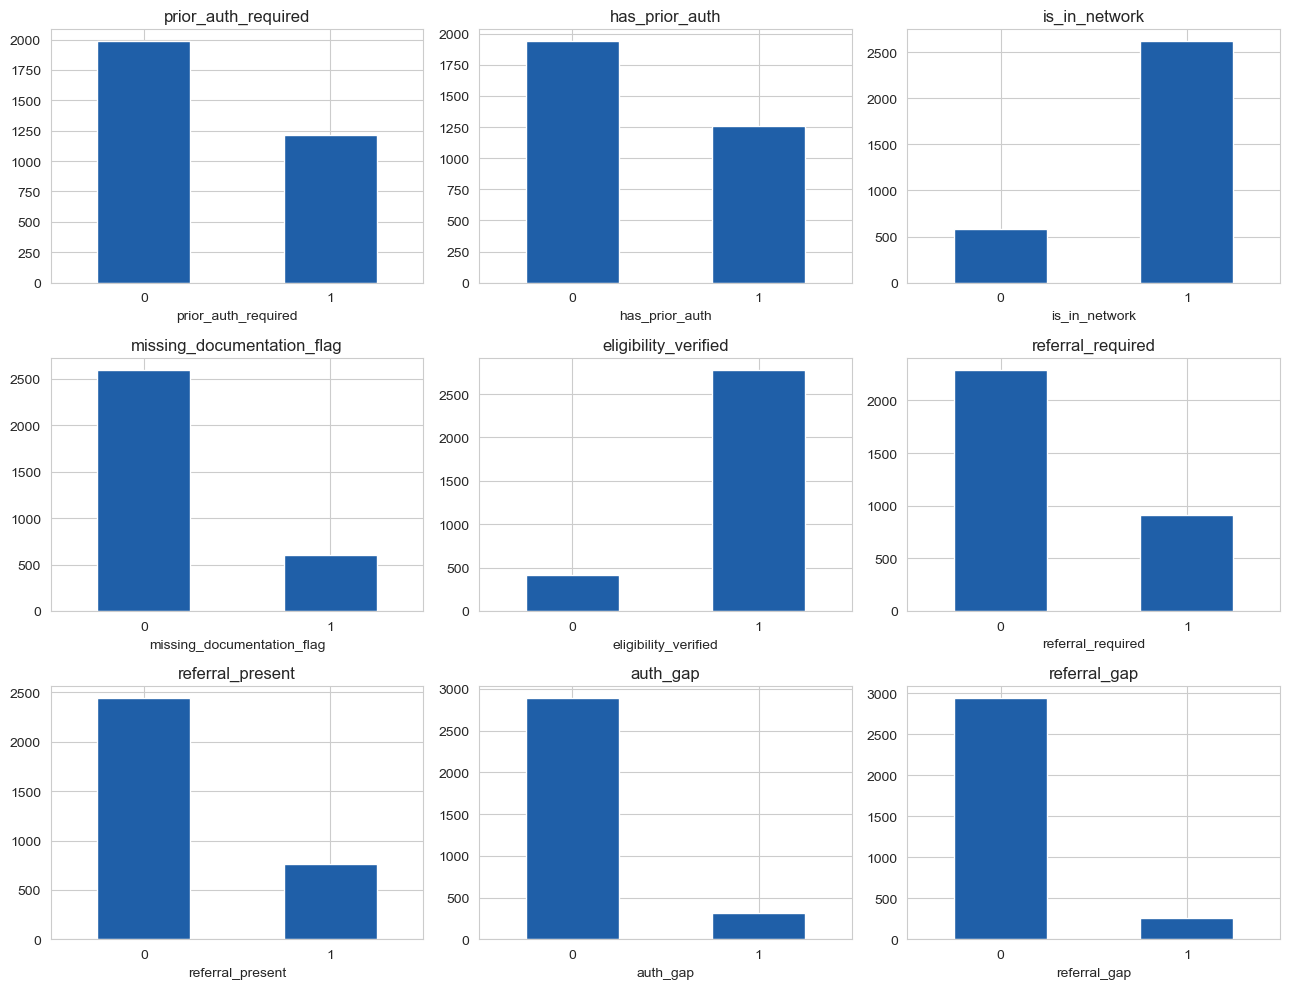

In [11]:
binary_cols = ["prior_auth_required", "has_prior_auth", "is_in_network",
               "missing_documentation_flag", "eligibility_verified",
               "referral_required", "referral_present", "auth_gap", "referral_gap"]
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, binary_cols):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="#1f5fa8")
    ax.set_title(col)
    ax.set_xticklabels(["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

**Inference:** Most flags are imbalanced toward the "good" state, as
expected for a functioning claims process: most claims have authorization,
eligibility verified, and documentation present. `auth_gap` and
`referral_gap` (the engineered features) are rare by construction (they only
trigger when a required approval is missing) -- rare but, per the bivariate
analysis below, highly predictive when they do trigger. This is a classic
"rare but high-signal" pattern.

## 2. Bivariate Analysis (vs. `is_denied`)

### 2.1 Denial rate by binary flag

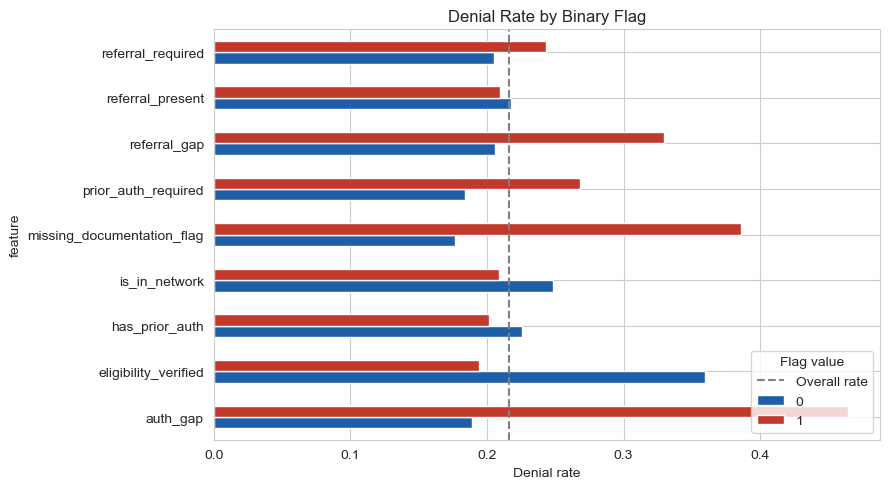

value,0,1
feature,,
auth_gap,0.189,0.465
eligibility_verified,0.360,0.194
has_prior_auth,0.225,0.201
is_in_network,0.249,0.209
missing_documentation_flag,0.176,0.386
prior_auth_required,0.184,0.268
referral_gap,0.206,0.330
referral_present,0.218,0.209
referral_required,0.205,0.243


In [12]:
rows = []
for col in binary_cols:
    for val in [0, 1]:
        subset = df[df[col] == val]
        if len(subset) > 0:
            rows.append({"feature": col, "value": val, "denial_rate": subset["is_denied"].mean(), "n": len(subset)})
flag_rates = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5))
pivot = flag_rates.pivot(index="feature", columns="value", values="denial_rate")
pivot.plot(kind="barh", ax=ax, color=["#1f5fa8", "#c0392b"])
ax.axvline(df["is_denied"].mean(), color="gray", linestyle="--", label="Overall rate")
ax.set_xlabel("Denial rate")
ax.legend(title="Flag value", loc="lower right")
ax.set_title("Denial Rate by Binary Flag")
plt.tight_layout()
plt.show()

flag_rates.pivot(index="feature", columns="value", values="denial_rate").round(3)

**Inference:** `auth_gap=1` and `referral_gap=1` show by far the largest
lift above the ~22% baseline denial rate (auth_gap: ~46%, more than double
baseline). `missing_documentation_flag=1` (~39%) and `eligibility_verified=0`
(~36%) are the next strongest signals. This directly confirms
these are the highest-value pre-submission checks for a review team, and
matches the model's own SHAP-based feature importance ranking in
`outputs/figures/feature_importance.png` -- the statistical signal in the raw
data and what the model actually learned agree.

### 2.2 Denial rate by categorical feature

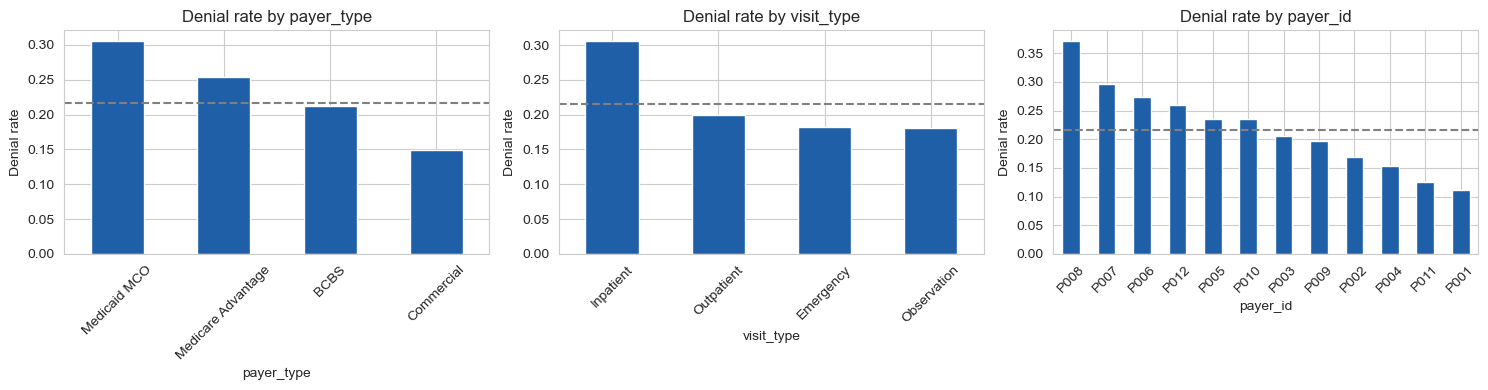

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["payer_type", "visit_type", "payer_id"]):
    rates = df.groupby(col)["is_denied"].mean().sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color="#1f5fa8")
    ax.axhline(df["is_denied"].mean(), color="gray", linestyle="--")
    ax.set_title(f"Denial rate by {col}")
    ax.set_ylabel("Denial rate")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Inference:** Denial rate varies more by `payer_type` than by `visit_type`
-- some payer types run several points above/below the overall baseline,
which is why `payer_type` is one-hot encoded as a model feature. `payer_id`
shows the widest spread of any categorical (from ~11% to ~37% denial rate
across the 12 payers) -- individual payers really do differ substantially in
their denial behavior, which is exactly why `payer_id` is also kept as a
model feature rather than dropped in favor of the coarser `payer_type`.

### 2.3 Numeric features by denial outcome

/var/folders/k1/82q9615j4v5000ddd6tfbgw40000gp/T/ipykernel_35308/1090723897.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_denied", y=col, ax=ax, palette=["#1f5fa8", "#c0392b"])
/var/folders/k1/82q9615j4v5000ddd6tfbgw40000gp/T/ipykernel_35308/1090723897.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Denied", "Denied"])
/var/folders/k1/82q9615j4v5000ddd6tfbgw40000gp/T/ipykernel_35308/1090723897.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_denied", y=col, ax=ax, palette=["#1f5fa8", "#c0392b"])
/var/folders/k1/82q9615j4v5000ddd6tfbgw40000g

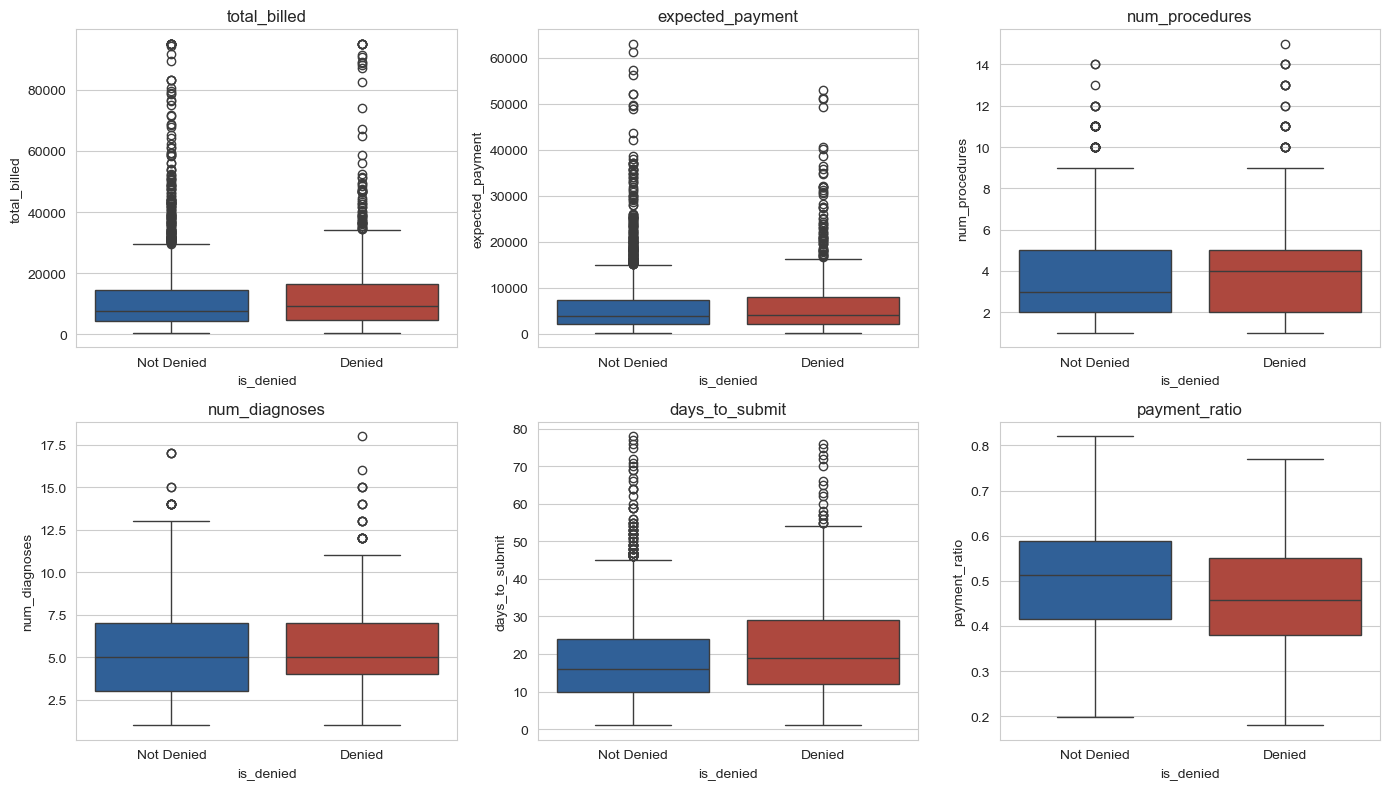

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=df, x="is_denied", y=col, ax=ax, palette=["#1f5fa8", "#c0392b"])
    ax.set_xticklabels(["Not Denied", "Denied"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Inference:** `days_to_submit` shows a visible shift -- denied claims skew
toward longer submission delays, consistent with "Claim submitted after
timely filing deadline" being one of the eight denial reasons. `payment_ratio`
is slightly lower for denied claims. `total_billed`, `expected_payment`,
`num_procedures`, and `num_diagnoses` show only mild differences between the
two groups -- these numeric fields carry weaker standalone signal than the
binary approval/documentation flags, which matches their lower ranking in the
model's SHAP feature importance.

### 2.4 Correlation among numeric features

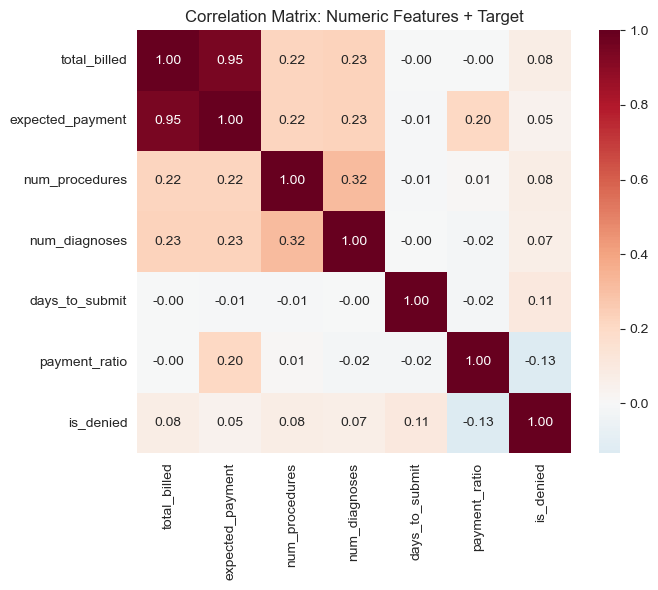

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df[numeric_cols + ["is_denied"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation Matrix: Numeric Features + Target")
plt.tight_layout()
plt.show()

**Inference:** `total_billed` and `expected_payment` are very highly
correlated (r=0.95), which makes sense -- `expected_payment` is a
contracted-rate function of `total_billed`. This is exactly the redundancy
`payment_ratio` (= expected_payment / total_billed) was engineered to
capture as a single feature instead of two nearly-collinear ones; the
modeling pipeline keeps both raw amounts too, but a linear model's
coefficients on `total_billed` and `expected_payment` individually should be
read with that collinearity in mind. All other numeric feature pairs are
only mildly correlated (|r| well under 0.35). Correlation of any single
numeric feature with `is_denied` is weak on its own (all under ~0.13 in
magnitude, `payment_ratio` slightly negative), reinforcing the earlier
finding: the categorical/binary approval and documentation flags are doing
the real predictive work, not the raw dollar amounts or code counts.

### 2.5 Sanity check: denial rate is consistent across train/validation/test

In [16]:
split_rates = df.groupby("split")["is_denied"].agg(["mean", "count"]).loc[["train", "validation", "test"]]
split_rates.columns = ["denial_rate", "n"]
split_rates

,denial_rate,n
split,,
train,0.211122,2122
validation,0.191095,539
test,0.259740,539


**Inference:** Denial rate is 21.1% (train), 19.1% (validation), and 26.0%
(test) -- some batch-to-batch variation, as expected with a 22% base rate and
a few hundred rows per split, but no split is wildly out of line with the
others. This means model evaluation on the test set isn't being distorted by
a systematically different population, and validation-derived thresholds
should transfer reasonably to test.

## 3. Summary of Key Findings

1. **`auth_gap` (prior authorization required but missing) and
   `missing_documentation_flag` are the strongest individual predictors of
   denial** -- both roughly double the baseline denial rate. These are also
   the top two features by model-derived SHAP importance, so the raw
   statistical signal and the trained model agree.
2. **Denial reasons are spread across 8 roughly-even categories** -- there is
   no single fix that eliminates most denials; a review checklist needs to
   cover authorization, documentation, eligibility, referrals, timely filing,
   coding, and network status.
3. **Numeric fields (billed amount, payment ratio, procedure/diagnosis
   counts) carry weaker standalone signal than the binary approval/
   documentation flags** -- `days_to_submit` is the one numeric exception,
   showing a visible shift for denied claims (consistent with the
   "submitted after timely filing deadline" denial reason).
4. **The target is moderately imbalanced (~22% denied)** -- enough to justify
   `class_weight="balanced"` and recall@25%/PR-AUC as headline metrics rather
   than plain accuracy, but not so extreme that resampling is required.
5. **`payer_id` denial rates vary meaningfully across payers** -- from ~11%
   to ~37% across the 12 payers in the training history -- which is why
   `payer_id` is kept as a model feature alongside the coarser `payer_type`.

These findings directly informed the feature engineering (`auth_gap`,
`referral_gap`, `payment_ratio` in `src/data.py`), the metric choice
(recall@25% in `src/metrics.py`), and the data findings reported in
`writeup/writeup.pdf`.